### 1. Prerequisitos

#### 1.1 Paquetes
Instalación de paquetes requeridos para la ejecución adecuada del Notebook

In [1]:
!pip install --quiet -r requirements.txt

#### 1.2 Librerías
Importación de librerías requeridas para la ejecución adecuada del Notebook

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification,AutoConfig
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,  classification_report
from tqdm.auto import tqdm
from pathlib import Path
import matplotlib.pyplot as plt

#### 1.3 Variables comúnes
Asignación de variables que son utilizadas en diferentes puntos del Notebook

In [3]:
MODEL_NAME = "google/electra-small-discriminator"
MAX_TOKENS = 512
BATCH_SIZE = 1
EPOCHS = 1
LR = 2e-5
RANDOM_SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DATA_PREPR = Path("./data-sources/pre-processed")
DATA_PREPR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = Path("./models/classifier/contextual")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

### 2. Datos

#### 2.1 Carga de datos
Carga de los datos a ser utilizados para el entrenamiento del modelo, se va a utilizar `google/electra-small-discriminator`

In [4]:
csv_files = sorted(DATA_PREPR.glob("data_chunk_*.csv"))

df_list = []
for f in csv_files:
    df_part = pd.read_csv(f)
    df_list.append(df_part)
data = pd.concat(df_list, ignore_index=True)
print(data.shape)
data.head()

(58963, 2)


,text,pls
0,Background\nThis is an update of a review publ...,0
1,Background\nPolycystic ovary syndrome (PCOS) i...,0
2,Background\nDysmenorrhoea is a common gynaecol...,0
3,Background\nDental caries is a sugar‐dependent...,0
4,Background\nOur March 2021 edition of this rev...,0


#### 2.2 Distribución
Distribución de los datos por cada uno de sus grupos (Texto Cientifico y PLS)

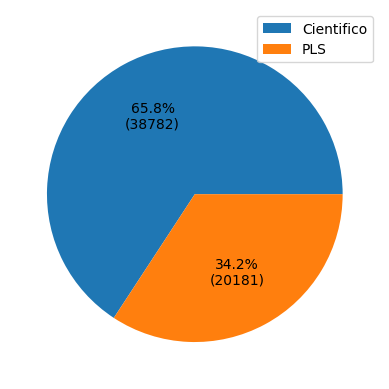

In [5]:
def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

pls_label = {0: 'Cientifico',1: 'PLS'}

df_temp = data.groupby(['pls']).size().to_frame(name='count').reset_index()
df_temp['pls'] = df_temp['pls'].replace(pls_label)

plt.pie(df_temp['count'],autopct=autopct_format(df_temp['count']))
plt.legend(df_temp['pls'])
plt.show()

#### 2.3 División de los datos
Se utiliza el 40% del dataset, y su división de datos en Entrenamiento, Test y Validación, sus porcentajes son 70%, 15% y 15% respectivamente

In [6]:
df_train, df_temp = train_test_split(data, test_size=0.3,random_state=RANDOM_SEED,stratify=data['pls'])
df_test, df_val = train_test_split(df_temp,test_size=0.5,random_state=RANDOM_SEED,stratify=df_temp['pls'])

print(f'Cantidad de registros dataset entrenamiento: {len(df_train)}, porcentaje {len(df_train)/len(data):.0%}')
print(f'Cantidad de registros dataset validación: {len(df_val)}, porcentaje {len(df_val)/len(data):.0%}')
print(f'Cantidad de registros dataset test: {len(df_test)}, porcentaje {len(df_test)/len(data):.0%}')

Cantidad de registros dataset entrenamiento: 41274, porcentaje 70%
Cantidad de registros dataset validación: 8845, porcentaje 15%
Cantidad de registros dataset test: 8844, porcentaje 15%


### 3. Entrenamiento

#### 3.1 Clases requeridas
Definición de la clases y fnciones requeridas para el entrenamiento del modelo

In [7]:
config    = AutoConfig.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_POS   = int(getattr(config, "max_position_embeddings", 512))
SPECIALS  = tokenizer.num_special_tokens_to_add(pair=False)
CHUNK_LEN = max(8, MAX_POS - SPECIALS)


tokenizer.model_max_length = MAX_POS

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [8]:
def chunk_ids(text: str):
    """
    Convierte texto -> ids (sin especiales) y divide en fragmentos que,
    al añadir especiales y pad, NO superen MAX_POS.
    """
    ids = tokenizer.encode(text, add_special_tokens=False)
    if not ids:
        ids = [tokenizer.pad_token_id]
    return [ids[i:i+CHUNK_LEN] for i in range(0, len(ids), CHUNK_LEN)]

In [9]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.texts  = df["text"].tolist()
        self.labels = df["pls"].tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        return {"text": str(self.texts[idx]), "label": int(self.labels[idx])}

In [10]:
def collate_fn(batch):
    item = batch[0]

    chunks = chunk_ids(item["text"])
    encoded = [
        tokenizer.prepare_for_model(
            ch,
            truncation=True,
            padding="max_length",
            max_length=MAX_POS,
            return_tensors="pt"
        )
        for ch in chunks
    ]

    input_ids      = torch.cat([e["input_ids"] for e in encoded], dim=0)
    attention_mask = torch.cat([e["attention_mask"] for e in encoded], dim=0)

    if input_ids.dim() == 1:      input_ids = input_ids.unsqueeze(0)
    if attention_mask.dim() == 1: attention_mask = attention_mask.unsqueeze(0)

    label = torch.tensor(item["label"], dtype=torch.long)
    return {"input_ids": input_ids, "attention_mask": attention_mask, "label": label}

In [11]:
class LongTextClassifier(nn.Module):
    def __init__(self, base_model_name: str, num_labels: int = 2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        self.hidden  = int(getattr(self.encoder.config, "hidden_size", 768))
        self.max_pos = int(getattr(self.encoder.config, "max_position_embeddings", 512))
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(self.hidden, num_labels)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        if input_ids.size(1) > self.max_pos:
            input_ids = input_ids[:, :self.max_pos]
        if attention_mask.size(1) > self.max_pos:
            attention_mask = attention_mask[:, :self.max_pos]

        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        doc_embed = cls.mean(dim=0, keepdim=True)
        logits = self.classifier(self.dropout(doc_embed))
        return logits

In [12]:
train_loader = DataLoader(TextDataset(df_train), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TextDataset(df_val),   batch_size=1,          shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TextDataset(df_test),  batch_size=1,          shuffle=False, collate_fn=collate_fn)

### 3.2 Entrenamiento del modelo

In [13]:
model = LongTextClassifier(MODEL_NAME).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    loss_sum = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        label     = batch["label"].to(DEVICE)

        if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
        if attn_mask.dim() == 1: attn_mask = attn_mask.unsqueeze(0)

        logits = model(input_ids=input_ids, attention_mask=attn_mask)
        loss   = criterion(logits, label.unsqueeze(0))
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()

    print(f"Epoch {epoch+1} | Train Loss: {loss_sum/len(train_loader):.4f}")

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            label     = batch["label"].to(DEVICE)

            if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
            if attn_mask.dim() == 1: attn_mask = attn_mask.unsqueeze(0)

            logits = model(input_ids=input_ids, attention_mask=attn_mask)
            preds.append(torch.argmax(logits, dim=1).cpu().item())
            trues.append(label.cpu().item())


Epoch 1:   0%|          | 0/41274 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (788 > 512). Running this sequence through the model will result in indexing errors
You're using a ElectraTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch 1 | Train Loss: 0.0142


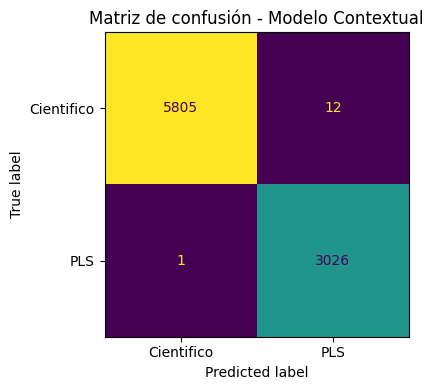

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
conf_mtx = confusion_matrix(trues, preds)
disp = ConfusionMatrixDisplay(conf_mtx, display_labels=['Cientifico', 'PLS'])
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión - Modelo Contextual")
plt.tight_layout()
plt.show()

fig.savefig(MODEL_PATH/"cm_train_modelo_contextual.png", dpi=150, bbox_inches="tight")

In [15]:
report_txt=classification_report(trues, preds,digits=4)
print(report_txt)
with open(MODEL_PATH/"cr_train_modelo_contextual.txt", "w", encoding="utf-8") as f:
    f.write(f"Modelo: Contextual\n")
    f.write(report_txt)

              precision    recall  f1-score   support

           0     0.9998    0.9979    0.9989      5817
           1     0.9961    0.9997    0.9979      3027

    accuracy                         0.9985      8844
   macro avg     0.9979    0.9988    0.9984      8844
weighted avg     0.9985    0.9985    0.9985      8844



In [16]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        label     = batch["label"].to(DEVICE)

        if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
        if attn_mask.dim() == 1: attn_mask = attn_mask.unsqueeze(0)

        logits = model(input_ids=input_ids, attention_mask=attn_mask)
        preds.append(torch.argmax(logits, dim=1).cpu().item())
        trues.append(label.cpu().item())


Testing:   0%|          | 0/8845 [00:00<?, ?it/s]

In [17]:
report_txt=classification_report(trues, preds,digits=4)
print(report_txt)

              precision    recall  f1-score   support

           0     0.9997    0.9990    0.9993      5818
           1     0.9980    0.9993    0.9987      3027

    accuracy                         0.9991      8845
   macro avg     0.9988    0.9992    0.9990      8845
weighted avg     0.9991    0.9991    0.9991      8845



In [18]:
torch.save(model.state_dict(), MODEL_PATH/"model_state_dict.pt")

In [19]:
model = LongTextClassifier(MODEL_NAME).to(DEVICE)
state = torch.load(MODEL_PATH/'model_state_dict.pt', map_location=DEVICE)
model.load_state_dict(state)
model.eval()

LongTextClassifier(
  (encoder): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_featur

In [20]:
@torch.no_grad()
def predict_one(text: str):
    chunks = chunk_ids(text)
    encoded = [
        tokenizer.prepare_for_model(
            ch, truncation=True, padding="max_length",
            max_length=MAX_POS, return_tensors="pt"
        )
        for ch in chunks
    ]
    input_ids      = torch.cat([e["input_ids"] for e in encoded], dim=0).to(DEVICE)
    attention_mask = torch.cat([e["attention_mask"] for e in encoded], dim=0).to(DEVICE)

    if input_ids.dim() == 1: input_ids = input_ids.unsqueeze(0)
    if attention_mask.dim() == 1: attention_mask = attention_mask.unsqueeze(0)

    logits = model(input_ids=input_ids, attention_mask=attention_mask)
    #probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
    pred  = int(torch.argmax(logits, dim=-1).item())
    return pred


In [21]:
print(df_val['text'].iloc[5])
print(df_val['pls'].iloc[5])
out = predict_one(df_val['text'].iloc[5])
print(out)

Background
The risk of cytomegalovirus (CMV) infection in solid organ transplant recipients has resulted in the frequent use of prophylaxis with the aim of preventing the clinical syndrome associated with CMV infection. This is an update of a review first published in 2005 and updated in 2008. 
Objectives
To determine the benefits and harms of antiviral medications to prevent CMV disease and all‐cause mortality in solid organ transplant recipients. 
Search methods
We searched MEDLINE, EMBASE and the Cochrane Central Registry of Controlled Trials (CENTRAL) in The Cochrane Library to February 2004 for the first version of this review. The Cochrane Renal Group's specialised register was searched to February 2007 and to July 2011 for the first and current updates of the review without language restriction. 
Selection criteria
We included randomised controlled trials (RCTs) and quasi‐RCTs comparing antiviral medications with placebo or no treatment, comparing different antiviral medications